In [49]:
import sys
sys.path.append('..')
from utils.filters import *
from hydra import compose, initialize
from utils.data_parsing_tools import load_data_bases
from utils.baseline_tools import *
import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
from utils.display_tools import load_best_forecasts, display_predictions, display_predictions_2
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.general_tools import pd_to_param_holder
import functools as ft

import matplotlib.pyplot as plt
from utils.general_tools import results_to_pd
from utils.modeling_tools import perform_modeling_sarimax, perform_modeling_varmax
from statsmodels.datasets import sunspots
from statsmodels.tsa.deterministic import Fourier

In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
from hydra import compose, initialize
import sys
sys.path.append('..')
from utils.data_parsing_tools import load_data_bases
import matplotlib.pyplot as plt
from numpy import linspace
from matplotlib.pyplot import cm



## Display the forecasts and save them properly into a table

In [54]:
with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="grid_config.yaml")
    
cfg.source_path= "../../raw_data/"
cfg.dir = "ps"
cfg.cache_path = "../../save_and_results"

/home/gideon/miniconda3/envs/ki4ki/lib/python3.13/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'grid_config.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [56]:
ps, exogs = load_data_bases(cfg)


Load cached data
Load cached data


Text(0, 0.5, '')

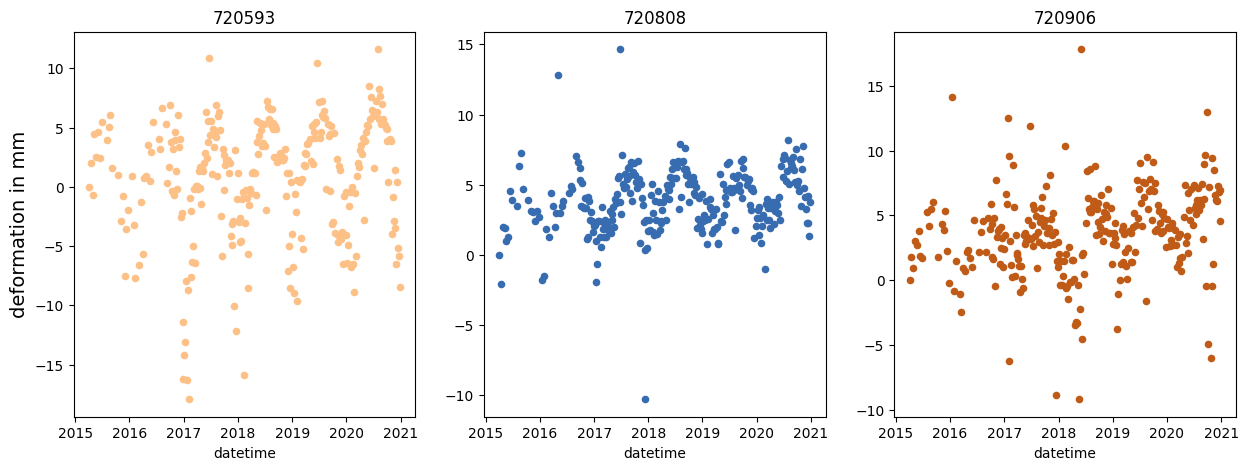

In [57]:
fix, axs = plt.subplots(1,3, figsize=(15,5))
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)

for n,x in enumerate(["720593","720808","720906"]):
    ps["Lister"]["asc0"].reset_index().plot.scatter(x="datetime", y= x , color = colors[n+1], ax= axs[n])
    axs[n].set_title(x)
axs[0].set_ylabel("deformation in mm", fontsize=14)
axs[1].set_ylabel("", fontsize=14)
axs[2].set_ylabel("", fontsize=14)

In [64]:
# Relevant parameters

loc = "Lister"
direction = "asc0"
row_length = 2

d = ps[loc][direction]
y_ = d.loc[d.index.year == 2020]

save_path = "../../save_and_results/old/"

In [65]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts(save_path + "/igarss/fc_igarss", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score

# Performance visualization

Position = 200.0
Position = 200.0
Position = 200.0
Position = 200.0


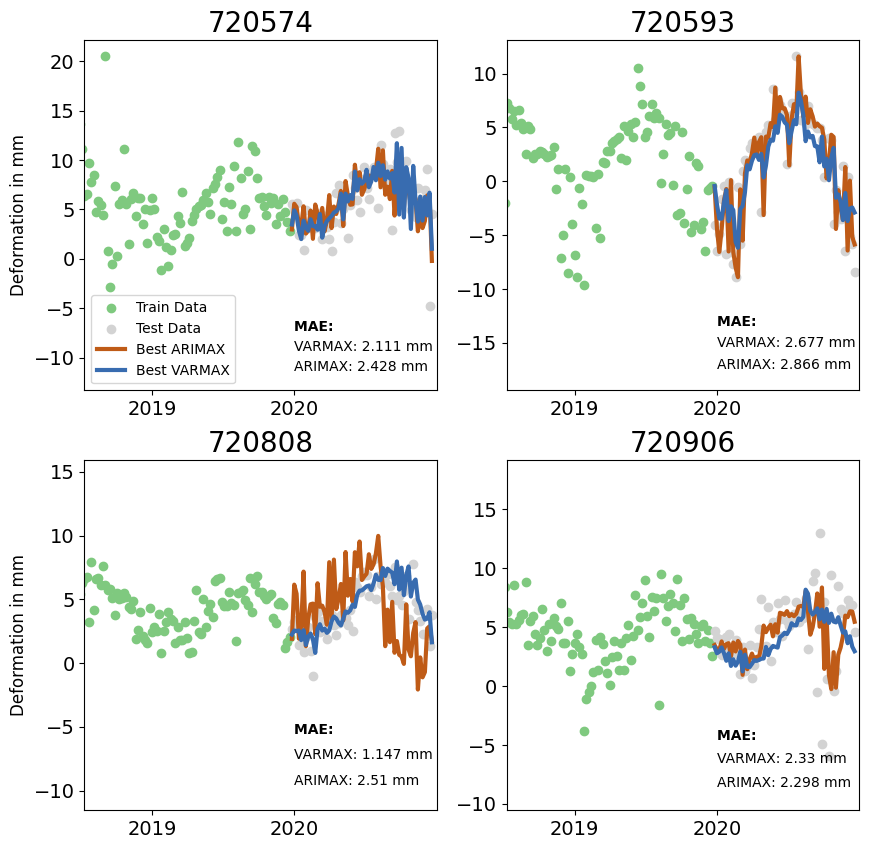

In [66]:
tickPos = np.where(d.index.isocalendar().week == 2)[0]
tickPos = [x for x in tickPos if x - 1 not in tickPos]
tickLabels = np.arange(2016, 2021)

cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)

rows = int(len(d.columns)/ row_length)
fig, axs = plt.subplots(rows, row_length, figsize=(5 * row_length, 5 * rows))
axs = axs.reshape(-1)
for n, key in enumerate(d.columns):
    train = d.loc[d.index.year < 2020, key].interpolate()
    test = d.loc[d.index.year >= 2020, key].interpolate()

    axs[n].scatter(np.arange(len(train)), train.values, label="Train Data", color = colors[0])
    axs[n].scatter(np.arange(len(train), len(train)+ len(test)), test, label="Test Data", color="lightgrey")

    axs[n].set_title(key, fontsize=20)
    axs[n].tick_params(
        axis="both", which="major", labelsize=14
    )

    axs[n].set_xticks(
        ticks=tickPos, labels=tickLabels, fontsize=14
    )
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], fc["sarimax"][key][:61], color = colors[3],alpha=1, linewidth=3, label="Best ARIMAX")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], sa_n[key], color="black", linewidth=3, label="Sarimax new")
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], fc["var"][key][:61], color = colors[2], linewidth=3, label="Best VARMAX")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], f_n[key], color="darkblue", linewidth=3, label="Random forest")
    axs[n].set_xlim([200,351])
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+6,"MAE: " , weight='bold')
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+4,"VARMAX: " + str(round(mae["var"].loc[key].values[0],3)) + " mm")
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+2,"ARIMAX: " + str(round(mae["sarimax"].loc[key].values[0],3)) + " mm")
    print("Position =" , axs[n].get_xlim()[0])
axs[0].legend()


axs[0].set_ylabel("Deformation in mm", fontsize=12)
axs[2].set_ylabel("Deformation in mm", fontsize=12)

#fig.suptitle('Forecast for 2020 at the Lister', fontsize=20)

fig.savefig("../../imgs/igarss_1", dpi=300)

## Rerun

In [61]:
# some ugly refractor because of loading:
for key in ["sarimax","var"]: #  "var"
    for y in ["T", "STAU"]:
        stack = []
        for x in ms[key]["Index"]:
            split = ms[key].loc[ms[key]["Index"] == x, y].values[0][1:-1]
            if len (split) != 0:
                stack.append(
                    np.array(
                        split.split(" ")).astype(int)
                )
            else:
                stack.append(np.array([]))

        ms[key][y] = stack

/tmp/ipykernel_71500/3370888832.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms[key][y] = stack


In [62]:
%%capture
fc_stack = {}
model_stack = []
for model_type in ["sarimax", "var"]: # var
    print(model_type)
    preds = []
    for ind in ms[model_type]["Index"]:
        combo = pd_to_param_holder(ms[model_type], ind)
        (train,
        test,
        max_data,
        min_data,
        trend,
        seasonality,
        test_trend,
        test_seasonality) = (
        full_preprocessing_pipeline(ps[loc][direction], exogs[loc], combo, model_search=False)
        )
        #
        #test[1] = test[1].clip(lower=0,upper=1)
        
        if model_type == "sarimax":
            model = perform_modeling_sarimax(train[0][str(ind)], train[1], combo)

            if len(test[1].columns) != 0:
                append_model = model.append(test[0][str(ind)], refit=False, exog=test[1])
            else:
                append_model = model.append(test[0][str(ind)], refit=False)

            pred_one_step = append_model.predict(start=test[0].index[0])
            pred_one_step = pd.DataFrame(pred_one_step)
            pred_one_step.columns = [str(ind)]
            model_stack.append(append_model)
            
        else:
            model = perform_modeling_varmax(train[0], train[1], combo)
            if len(test[1].columns) != 0:
                append_res = model.append(test[0], refit=False, exog=test[1])
            else:
                append_res = model.append(test[0], refit=False)
            pred = append_res.predict(start=test[0].index[0])
            pred.columns = test[0].columns
            pred = pd.DataFrame(pred[str(ind)])
            pred.columns = [str(ind)]
            pred_one_step = pred

        # Transform to original range and appends results
        Y, Y_hat = bring_to_original_range(
            test[0][str(ind)],
            pred_one_step[str(ind)],
            max_data[str(ind)],
            min_data[str(ind)],
            (test_trend[str(ind)] if isinstance(trend, pd.DataFrame) else None),
            (test_seasonality[str(ind)] if isinstance(seasonality, pd.DataFrame) else None),
            ps[loc][direction],
            str(ind),
        )
        preds.append(Y_hat)
    preds = pd.concat(preds, axis=1)
    #preds.columns = ms[model_type]["Index"].values
    fc_stack[model_type] = preds

## Baseline performance

In [68]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts(save_path + "/igarss/fc_igarss_baseline", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score
mae

{'sarimax':              MAE
 720574  4.531750
 720593  4.190599
 720808  3.749778
 720906  3.937782}

In [118]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts(save_path + "/igarss/fc_igarss", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score
mae

{'var':              MAE
 720574  2.111268
 720593  2.677257
 720808  1.147231
 720906  2.329522,
 'sarimax':              MAE
 720574  2.428219
 720593  2.865795
 720808  2.509723
 720906  2.297597}

In [70]:




out_stack = []
for x in ["asc0", "desc0", "ew", "ver"]:
    mae = {}
    d = ps[loc][x]
    y_ = d.loc[d.index.year == 2020]
    model_spec, forecasts = load_best_forecasts(save_path + "igarss/fc_igarss_baseline", direction=x)
    

    for key in forecasts:
        score = pd.DataFrame(
            (np.abs(forecasts[key] - y_.values).mean().values),
            index=forecasts[key].columns,
            columns=["MAE"],
        )
        mae[key] = score

        out_stack.append(mae["sarimax"].mean())
pd.concat(out_stack,axis=1),pd.concat(out_stack,axis=1).mean(axis=1)

(            0         1         2         3
 MAE  4.102477  4.208289  4.103649  2.918006,
 MAE    3.833105
 dtype: float64)

In [108]:
out_stack = []
for x in ["asc0", "desc0", "ew", "ver"]:
    mae = {}
    d = ps[loc][x]
    y_ = d.loc[d.index.year == 2020]
    model_spec, forecasts = load_best_forecasts(save_path + "igarss/fc_igarss", direction=x)
    

    for key in forecasts:
        score = pd.DataFrame(
            (np.abs(forecasts[key] - y_.values).mean().values),
            index=forecasts[key].columns,
            columns=["MAE"],
        )
        mae[key] = score
    out_stack.append(mae)

In [74]:
pd.concat([x["var"].mean() for x in out_stack], axis=1),pd.concat([x["var"].mean() for x in out_stack], axis=1).mean(axis=1)

(           0         1         2         3
 MAE  2.06632  1.924844  1.795191  1.508346,
 MAE    1.823675
 dtype: float64)

In [75]:
pd.concat([x["sarimax"].mean() for x in out_stack], axis=1),pd.concat([x["sarimax"].mean() for x in out_stack], axis=1).mean(axis=1)

(            0         1         2         3
 MAE  2.525334  2.318257  2.019027  1.725855,
 MAE    2.147118
 dtype: float64)

# Training performance distribution ( Not used)

In [76]:
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Set2(x) for x in cm_subsection])
colors = list(colors)

In [100]:
origin = save_path + "igarss/igarss_new"

sar_grid = pickle.load(open(origin + "/" + loc + "_" + "asc0" + "_sarimax_results_stack.p", "rb"))            
var_grid = pickle.load(open(origin + "/" + loc + "_" + "asc0" + "_var_results_stack.p", "rb"))            
                
sar_grid  = results_to_pd(sar_grid)
var_grid  = results_to_pd(var_grid)

In [101]:
var_grid["MSE_1step"].clip(upper=25, inplace=True) # divergend values fuck up the plot

/tmp/ipykernel_71500/874576665.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  var_grid["MSE_1step"].clip(upper=25, inplace=True) # divergend values fuck up the plot


4


/tmp/ipykernel_71500/1515262498.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)


4


/tmp/ipykernel_71500/1515262498.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)


4


/tmp/ipykernel_71500/1515262498.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)


4


/tmp/ipykernel_71500/1515262498.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)


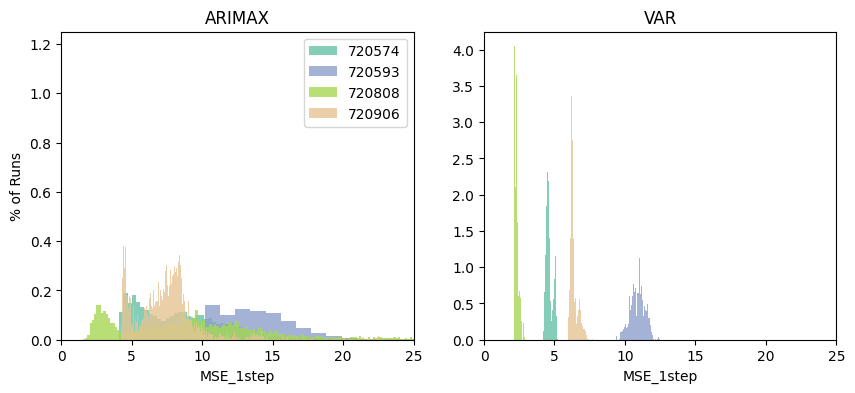

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
axs = axs.reshape(-1)

origin = "testing"

for n,p in enumerate(sar_grid["Index"].unique()):
    print(len(sar_grid["Index"].unique()))
    axs[0].hist(sar_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)
    axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)
axs[0].set_xlabel("MSE_1step")
axs[1].set_xlabel("MSE_1step")

axs[0].set_ylabel("% of Runs")
axs[0].set_xlim([0,25])
axs[1].set_xlim([0,25])
axs[0].set_ylim([0,1.25])
#axs[1].set_ylim([0,1.5])

axs[0].set_title("ARIMAX")
axs[1].set_title("VAR")

axs[0].legend()

#fig.suptitle("Performance Distribution of the model search space")

# Residual distributios

In [114]:
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)
d = ps["Lister"]["asc0"]
y_ = d.loc[d.index.year == 2020]

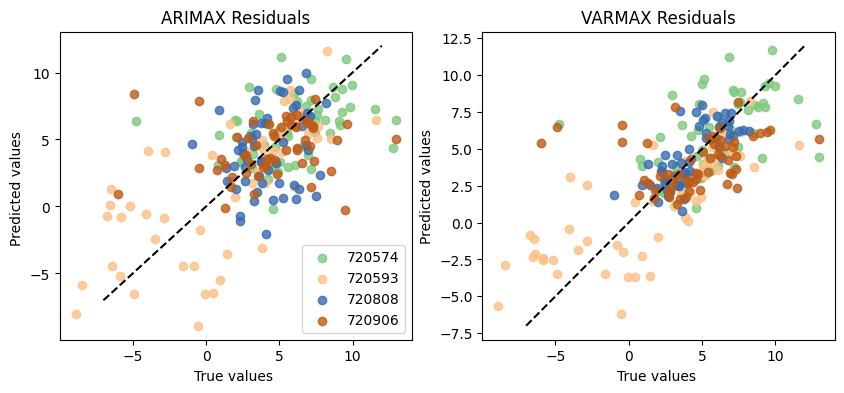

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
axs = axs.reshape(-1)

axs[0].plot(np.arange(-7,13),np.arange(-7,13), color = "black", linestyle = "dashed")
axs[1].plot(np.arange(-7,13),np.arange(-7,13), color = "black", linestyle = "dashed")

for n,x in enumerate(y_.columns):
    axs[0].scatter(y_[x].values,fc["sarimax"][x].values, label=x, color = colors[n], alpha=0.8 )
    axs[1].scatter(y_[x].values,fc["var"][x].values, label=x, color = colors[n], alpha=0.8 )

    axs[0].set_xlabel("True values ")
    axs[0].set_ylabel("Predicted values ")

    axs[1].set_xlabel("True values ")
    axs[1].set_ylabel("Predicted values")

axs[0].legend()
axs[0].set_title("ARIMAX Residuals")
axs[1].set_title("VARMAX Residuals")

#fig.suptitle('Residual distribution for Lister in ascending direction', fontsize=12)

fig.savefig("../../imgs/image_2.png", dpi=300)

# Parameter strength 

In [179]:
params = pickle.load(open("results/fc_igarss/Lister_asc0_sarimax_model_stack.p", "rb"))
paramsV = pickle.load(open("results/fc_igarss/Lister_asc0_var_model_stack.p", "rb"))

In [180]:
extract = [pd.DataFrame([ x[:2] for x in ((table.summary()).tables[1]).data[1:]]) for table in params]
extractV = [pd.DataFrame([ x[:2] for x in ((table.summary()).tables[2]).data[1:]]) for table in paramsV]

In [181]:
df_final = ft.reduce(lambda left, right: pd.merge(left, right, on=0, how="outer"), extract)
df_finalV = ft.reduce(lambda left, right: pd.merge(left, right, on=0, how="outer"), extractV)

In [182]:
df_final

,0,1_x,1_y,1_x,1_y
0,intercept,0.0631,0.0008,-0.0176,-0.0002
1,drift,4.617e-07,-5.825e-06,0.0004,-8.277e-07
2,sin_order_1,0.0148,NaN,-0.1376,-0.0023
3,cos_order_1,0.0416,NaN,0.0263,-0.0038
4,W_mean_3_0,0.9520,NaN,0.3057,1.3952
5,W_0,0.1764,NaN,NaN,-0.1769
6,W_1,-1.0714,NaN,NaN,-0.3863
7,T_0,0.3179,-0.0874,0.6615,NaN
8,ar.L1,0.6754,NaN,NaN,-0.4362
9,ar.L2,0.0676,NaN,NaN,-0.2753


In [187]:
pd.concat(
    [
        df_finalV[df_finalV[0].isin([x for x in df_finalV[0] if "T" in x])],
        df_finalV[df_finalV[0].isin([x for x in df_finalV[0] if "W" in x])],
    ]
)

,0,1_x,1_y,1_x,1_y
26,beta.T_mean_7_0,-0.0537,NaN,NaN,0.0392
28,beta.T_0,0.1461,NaN,0.1149,NaN
39,beta.T_mean_3_0,NaN,NaN,-0.3214,NaN
40,beta.T_1,NaN,NaN,0.0695,NaN
41,beta.T_2,NaN,NaN,0.2594,NaN
27,beta.W_0,0.0003,-0.1073,-0.1469,0.0300
29,beta.W_1,NaN,0.1197,0.2396,NaN
38,beta.W_mean_7_0,NaN,NaN,-0.0869,-0.0237


In [186]:
pd.concat(
    [
        df_final[df_final[0].isin([x for x in df_final[0] if "T" in x])],
        df_final[df_final[0].isin([x for x in df_final[0] if "W" in x])],
    ]
)

,0,1_x,1_y,1_x,1_y
7,T_0,0.3179,-0.0874,0.6615,NaN
14,T_mean_3_0,NaN,0.0476,NaN,0.0363
4,W_mean_3_0,0.9520,NaN,0.3057,1.3952
5,W_0,0.1764,NaN,NaN,-0.1769
6,W_1,-1.0714,NaN,NaN,-0.3863
13,W_mean_7_0,NaN,-0.0158,NaN,NaN
15,W_2,NaN,NaN,NaN,-0.8671


In [178]:
pd.DataFrame(np.array([var_grid[var_grid.Index == x].sort_values("MSE")[:1].values[0] for x in var_grid.Index.unique()]), columns=var_grid.columns)

,Index,MSE,MAE,MSE_1step,MAE_1step,AIC,MAPE,MAPE_1step,P,D,...,STAU,T,M_Stau,M_T,Decompose,Interaction,Estimator,n_estimator,max_depth,learning_rate
0,720574,5.093458,-0.514565,5.554781,-0.616483,0.358716,0.382873,-1636.384042,0,None,...,[0],[0],3,0,1,0,None,None,None,None
1,720593,9.517886,-0.80372,10.403337,-1.452375,2.477206,2.479954,-1694.784499,2,None,...,"[0, 1]","[0, 1]",0,3,1,0,None,None,None,None
2,720808,1.531838,-0.01997,2.260407,-0.182268,0.305555,0.39111,-1963.856942,2,None,...,"[0, 1]",[0],0,0,0,0,None,None,None,None
3,720906,4.216344,0.76172,4.258746,0.763686,0.349495,0.347961,-1628.408297,0,None,...,[0],[0],0,3,1,0,None,None,None,None
